# SG-1 DC Project  Task 1: Spatial Feature Learning (Static CNN)
Trains a custom CNN to classify 26 ASL letters from the SignAlphaSet dataset.


In [19]:
# ── Cell 1: Imports & Config ─────────────────────────────────────────────────

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Config
CFG = {
    "data_root": "/kaggle/input/datasets/stellarsyntax/signalphaset/SignAlphaSet",
    "img_size"    : 128,
    "batch_size"  : 64,
    "num_workers" : 2,
    "epochs"      : 60,
    "lr"          : 3e-4,
    "weight_decay": 1e-4,
    "val_split"   : 0.15,
    "patience"    : 12,
    "num_classes" : 26,
    "save_path"   : "asl_cnn_weights.pth",
    "feature_dim" : 512,   # CNN output dim — fed into LSTM in Task 2
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [20]:
# ── Cell 2: Explore Dataset ──────────────────────────────────────────────────

data_root = Path(CFG["data_root"])


class_root = data_root   # class folders (A-Z) are directly here now

classes = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
print(f"Classes ({len(classes)}): {classes}")

counts = {c: len(list((class_root / c).glob("*"))) for c in classes}
print("\nSamples per class:")
for c, n in counts.items():
    print(f"  {c}: {n}")

class_root = find_class_dirs(data_root)
print(f"Class root: {class_root}")

classes = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
print(f"Classes ({len(classes)}): {classes}")

counts = {c: len(list((class_root / c).glob("*"))) for c in classes}
print("\nSamples per class:")
for c, n in counts.items():
    print(f"  {c}: {n}")

Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Samples per class:
  A: 1000
  B: 1000
  C: 1000
  D: 1000
  E: 1000
  F: 1000
  G: 1000
  H: 1000
  I: 1000
  J: 1000
  K: 1000
  L: 1000
  M: 1000
  N: 1000
  O: 1000
  P: 1000
  Q: 1000
  R: 1000
  S: 1000
  T: 1000
  U: 1000
  V: 1000
  W: 1000
  X: 1000
  Y: 1000
  Z: 1000
Class root: /kaggle/input/datasets/stellarsyntax/signalphaset/SignAlphaSet
Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Samples per class:
  A: 1000
  B: 1000
  C: 1000
  D: 1000
  E: 1000
  F: 1000
  G: 1000
  H: 1000
  I: 1000
  J: 1000
  K: 1000
  L: 1000
  M: 1000
  N: 1000
  O: 1000
  P: 1000
  Q: 1000
  R: 1000
  S: 1000
  T: 1000
  U: 1000
  V: 1000
  W: 1000
  X: 1000
  Y: 1000
  Z: 1000


In [21]:
# ── Cell 3: Dataset & Transforms ────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class RawASLDataset(Dataset):
    """Collects (path, label) pairs without applying transforms."""
    def __init__(self, root, classes):
        self.samples   = []
        self.class2idx = {c: i for i, c in enumerate(classes)}
        for cls in classes:
            for img_path in (root / cls).iterdir():
                if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                    self.samples.append((img_path, self.class2idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


class SplitDataset(Dataset):
    """Wraps a list of (path, label) pairs with a transform."""
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


# Build train / val splits
raw = RawASLDataset(class_root, classes)
n_val = int(len(raw) * CFG["val_split"])
indices = list(range(len(raw)))
random.shuffle(indices)

train_samples = [raw.samples[i] for i in indices[n_val:]]
val_samples   = [raw.samples[i] for i in indices[:n_val]]

train_ds = SplitDataset(train_samples, train_tf)
val_ds   = SplitDataset(val_samples,   val_tf)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 22100 | Val: 3900
Train batches: 346 | Val batches: 61


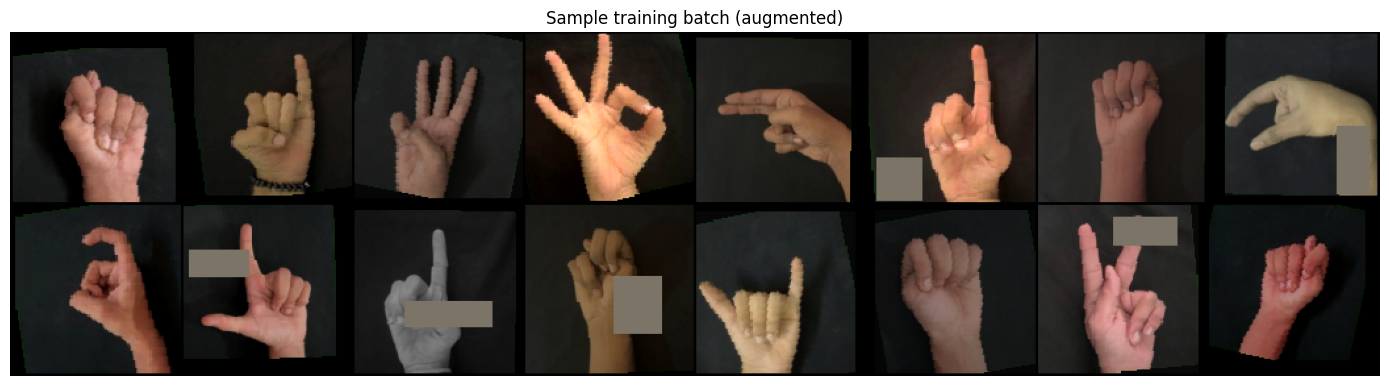

Labels: ['T', 'I', 'W', 'F', 'H', 'D', 'M', 'Q', 'X', 'L', 'D', 'N', 'Y', 'M', 'K', 'T']


In [22]:
# ── Cell 4: Visualise a Batch ────────────────────────────────────────────────

def denorm(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return torch.clamp(t * s + m, 0, 1)

imgs, labels = next(iter(train_loader))
grid = make_grid(denorm(imgs[:16]), nrow=8)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1,2,0).numpy())
plt.title("Sample training batch (augmented)")
plt.axis("off")
plt.tight_layout()
plt.savefig("sample_batch.png", dpi=120)
plt.show()
print("Labels:", [classes[l] for l in labels[:16]])

In [23]:
# ── Cell 5: CNN Architecture ─────────────────────────────────────────────────
#
# Stages:  3→32 (k=5) → 32→64 + 2×ResBlock+SE → 64→128 + 2×ResBlock+SE+1×1
#        → 128→256 + ResBlock+SE → 256→512 → GAP → 512-d → FC → 26 classes
#
# forward_features() exposes the 512-d vector for Task 2's LSTM.

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class ConvBlock(nn.Module):
    """Conv2d → BN → ReLU, with optional MaxPool."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pool=False):
        super().__init__()
        pad       = kernel // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()

    def forward(self, x):
        return self.pool(F.relu(self.bn(self.conv(x)), inplace=True))


class ResBlock(nn.Module):
    """Two ConvBlocks + skip connection + optional SE gate."""
    def __init__(self, channels, se=True):
        super().__init__()
        self.conv1 = ConvBlock(channels, channels, kernel=3)
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.se = SEBlock(channels) if se else nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.se(out)
        return F.relu(out + x, inplace=True)


class ASL_CNN(nn.Module):
    def __init__(self, num_classes=26, feature_dim=512, dropout=0.4):
        super().__init__()

        self.stage0 = ConvBlock(3, 32, kernel=5, pool=True)          # 128→64

        self.stage1 = nn.Sequential(
            ConvBlock(32, 64, kernel=3, pool=True),                   # 64→32
            ResBlock(64, se=True),
            ResBlock(64, se=True),
            nn.Dropout2d(0.10),
        )

        self.stage2 = nn.Sequential(
            ConvBlock(64, 128, kernel=3, pool=True),                  # 32→16
            ResBlock(128, se=True),
            ResBlock(128, se=True),
            nn.Conv2d(128, 128, kernel_size=1),                       # 1×1 mixing
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
        )

        self.stage3 = nn.Sequential(
            ConvBlock(128, 256, kernel=3, pool=True),                 # 16→8
            ResBlock(256, se=True),
            nn.Dropout2d(0.20),
        )

        self.stage4 = ConvBlock(256, feature_dim, kernel=3, pool=True)  # 8→4

        self.gap = nn.AdaptiveAvgPool2d(1)                            # → 512-d

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

        self.feature_dim = feature_dim
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward_features(self, x):
        """Returns the 512-d feature vector (Task 2 LSTM input)."""
        x = self.stage0(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.gap(x).flatten(1)     # (B, 512)

    def forward(self, x):
        return self.head(self.forward_features(x))   # (B, 26)


model = ASL_CNN(num_classes=CFG["num_classes"], feature_dim=CFG["feature_dim"]).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: {total/1e6:.2f}M total | {trainable/1e6:.2f}M trainable")

# Shape sanity check
dummy = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(DEVICE)
with torch.no_grad():
    print("Feature shape :", model.forward_features(dummy).shape)   # (2, 512)
    print("Logit shape   :", model(dummy).shape)                    # (2, 26)

Params: 3.66M total | 3.66M trainable
Feature shape : torch.Size([2, 512])
Logit shape   : torch.Size([2, 26])


In [24]:
# ── Cell 6: Loss, Optimiser & Scheduler ─────────────────────────────────────

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

# Cosine annealing with warm restarts — escapes plateaus every 15 epochs
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# Mixed precision scaler (speeds up training on T4/P100)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print("Loss       :", criterion)
print("Optimizer  :", type(optimizer).__name__)
print("Scheduler  :", type(scheduler).__name__)

Loss       : CrossEntropyLoss()
Optimizer  : AdamW
Scheduler  : CosineAnnealingWarmRestarts


/tmp/ipykernel_55/3257429557.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [25]:
# ── Cell 7: Training Loop ────────────────────────────────────────────────────

def accuracy(logits, labels):
    return (logits.argmax(1) == labels).float().mean().item()


def run_epoch(model, loader, criterion, optimizer, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            bs          = imgs.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy(logits, labels) * bs
            n          += bs

    return total_loss / n, total_acc / n


history      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
patience_ctr = 0

print(f"{'Epoch':>6} | {'T-Loss':>8} | {'T-Acc':>7} | {'V-Loss':>8} | {'V-Acc':>7} | {'LR':>9}")
print("-" * 62)

for epoch in range(1, CFG["epochs"] + 1):
    t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, scaler, train=True)
    v_loss, v_acc = run_epoch(model, val_loader,   criterion, optimizer, scaler, train=False)
    scheduler.step(epoch)
    lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    marker = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        patience_ctr = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "val_acc"    : v_acc,
            "cfg"        : CFG,
            "classes"    : classes,
        }, CFG["save_path"])
        marker = " ← best"
    else:
        patience_ctr += 1

    print(f"{epoch:>6} | {t_loss:>8.4f} | {t_acc*100:>6.2f}% | "
          f"{v_loss:>8.4f} | {v_acc*100:>6.2f}%{marker} | {lr:.2e}")

    if patience_ctr >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

 Epoch |   T-Loss |   T-Acc |   V-Loss |   V-Acc |        LR
--------------------------------------------------------------


/tmp/ipykernel_55/2605229877.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


     1 |   2.0325 |  47.64% |   0.9623 |  91.64% ← best | 2.97e-04
     2 |   1.0006 |  90.10% |   0.8042 |  98.64% ← best | 2.87e-04
     3 |   0.8249 |  96.47% |   0.7170 |  99.74% ← best | 2.71e-04
     4 |   0.7502 |  98.46% |   0.6748 | 100.00% ← best | 2.51e-04
     5 |   0.7129 |  99.11% |   0.6636 | 100.00% | 2.25e-04
     6 |   0.6913 |  99.42% |   0.6539 | 100.00% | 1.97e-04
     7 |   0.6810 |  99.56% |   0.6458 |  99.97% | 1.66e-04
     8 |   0.6736 |  99.62% |   0.6392 | 100.00% | 1.35e-04
     9 |   0.6664 |  99.75% |   0.6403 |  99.97% | 1.04e-04
    10 |   0.6633 |  99.77% |   0.6371 |  99.97% | 7.58e-05
    11 |   0.6594 |  99.83% |   0.6352 | 100.00% | 5.05e-05
    12 |   0.6575 |  99.81% |   0.6348 | 100.00% | 2.96e-05
    13 |   0.6560 |  99.88% |   0.6348 | 100.00% | 1.39e-05
    14 |   0.6555 |  99.86% |   0.6341 | 100.00% | 4.27e-06
    15 |   0.6548 |  99.90% |   0.6336 | 100.00% | 3.00e-04
    16 |   0.6870 |  99.12% |   0.6379 | 100.00% | 2.99e-04

Early stopp

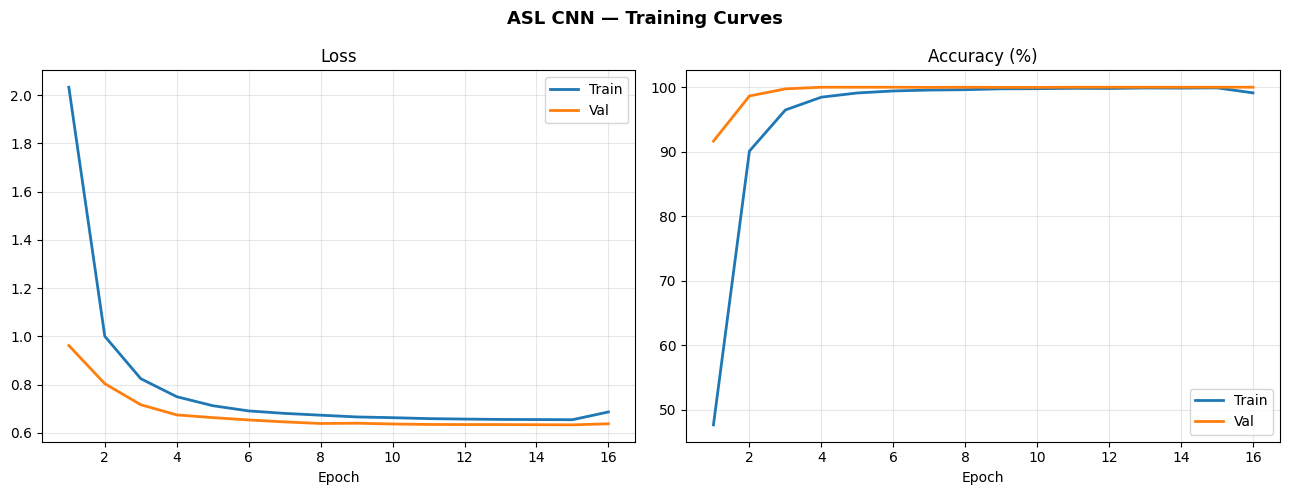

In [26]:
# ── Cell 8: Training Curves ──────────────────────────────────────────────────

epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, [a*100 for a in history["train_acc"]], label="Train", linewidth=2)
axes[1].plot(epochs_ran, [a*100 for a in history["val_acc"]],   label="Val",   linewidth=2)
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ASL CNN — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

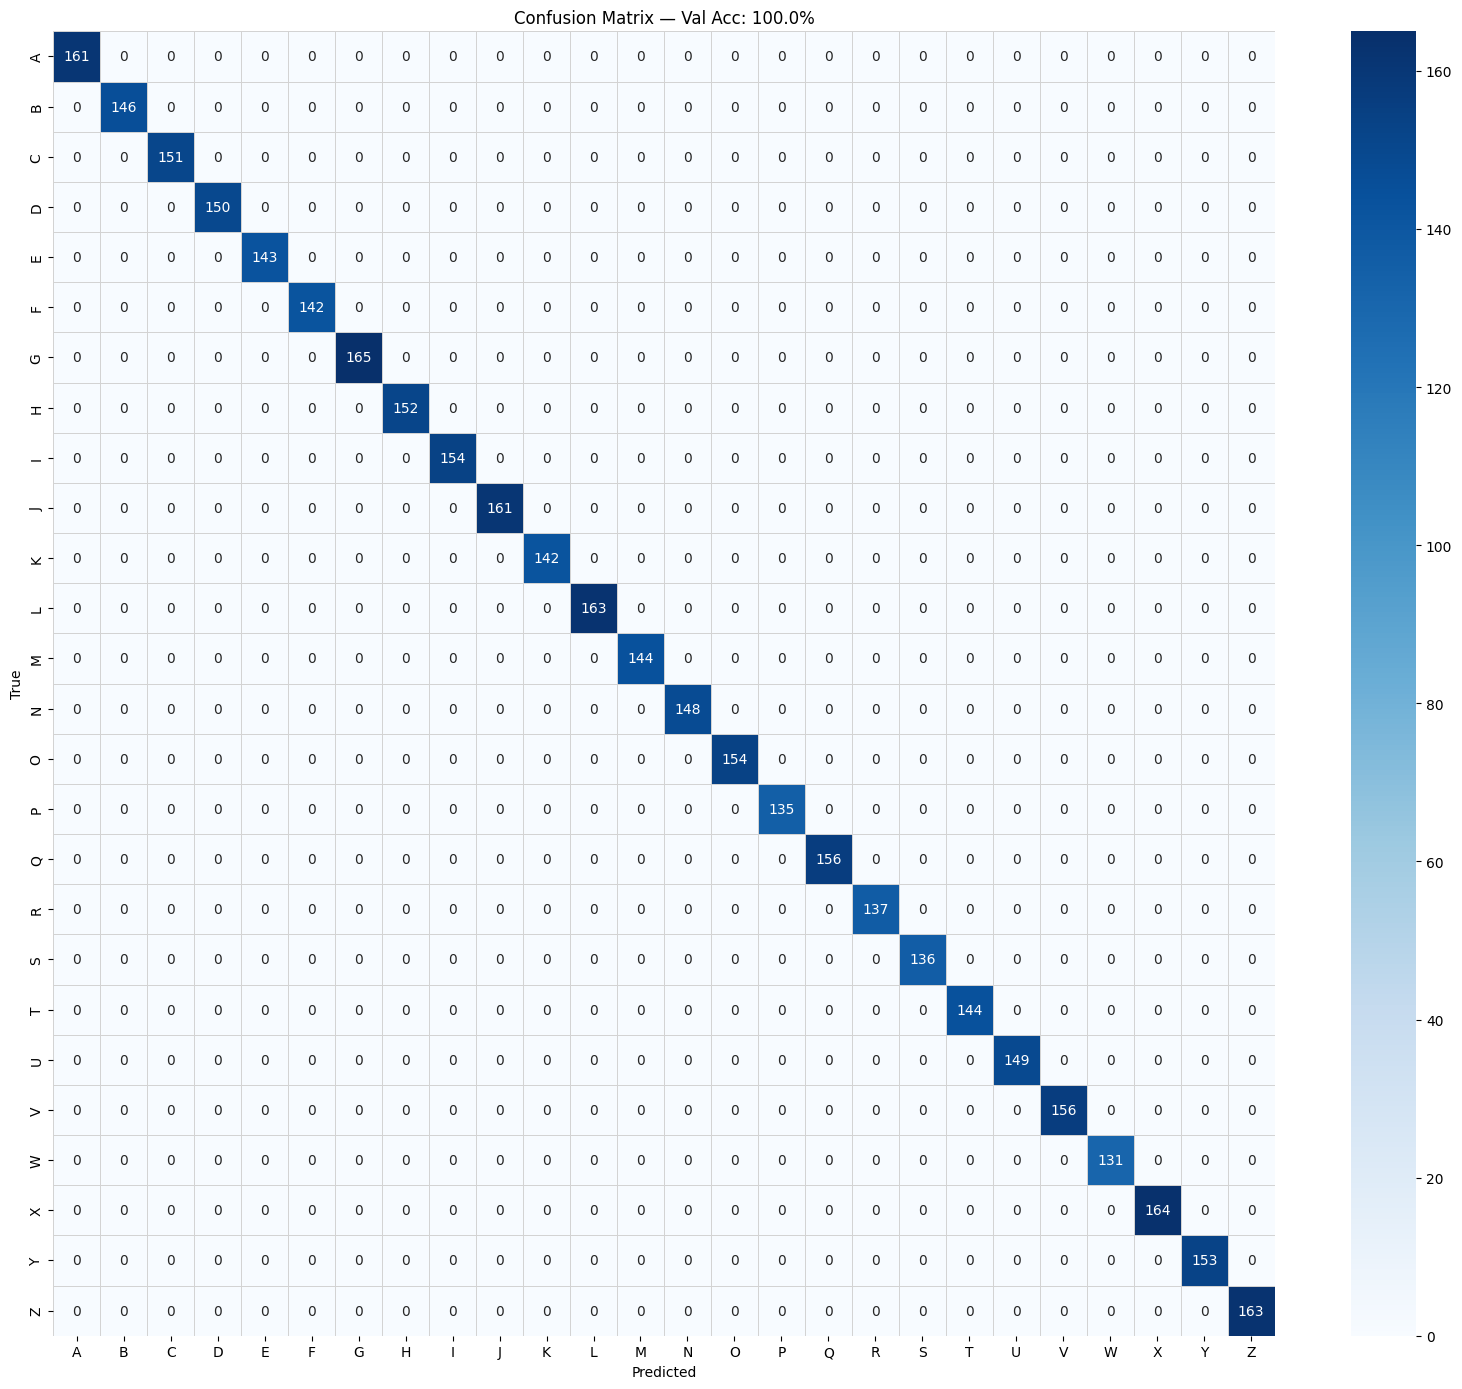


Per-class report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       161
           B       1.00      1.00      1.00       146
           C       1.00      1.00      1.00       151
           D       1.00      1.00      1.00       150
           E       1.00      1.00      1.00       143
           F       1.00      1.00      1.00       142
           G       1.00      1.00      1.00       165
           H       1.00      1.00      1.00       152
           I       1.00      1.00      1.00       154
           J       1.00      1.00      1.00       161
           K       1.00      1.00      1.00       142
           L       1.00      1.00      1.00       163
           M       1.00      1.00      1.00       144
           N       1.00      1.00      1.00       148
           O       1.00      1.00      1.00       154
           P       1.00      1.00      1.00       135
           Q       1.00      1.00      1.00       156
        

In [27]:
# ── Cell 9: Confusion Matrix ─────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best weights
ckpt = torch.load(CFG["save_path"], map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.4, linecolor="lightgray")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — Val Acc: {best_val_acc*100:.1f}%")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nPer-class report:")
print(classification_report(all_labels, all_preds, target_names=classes))

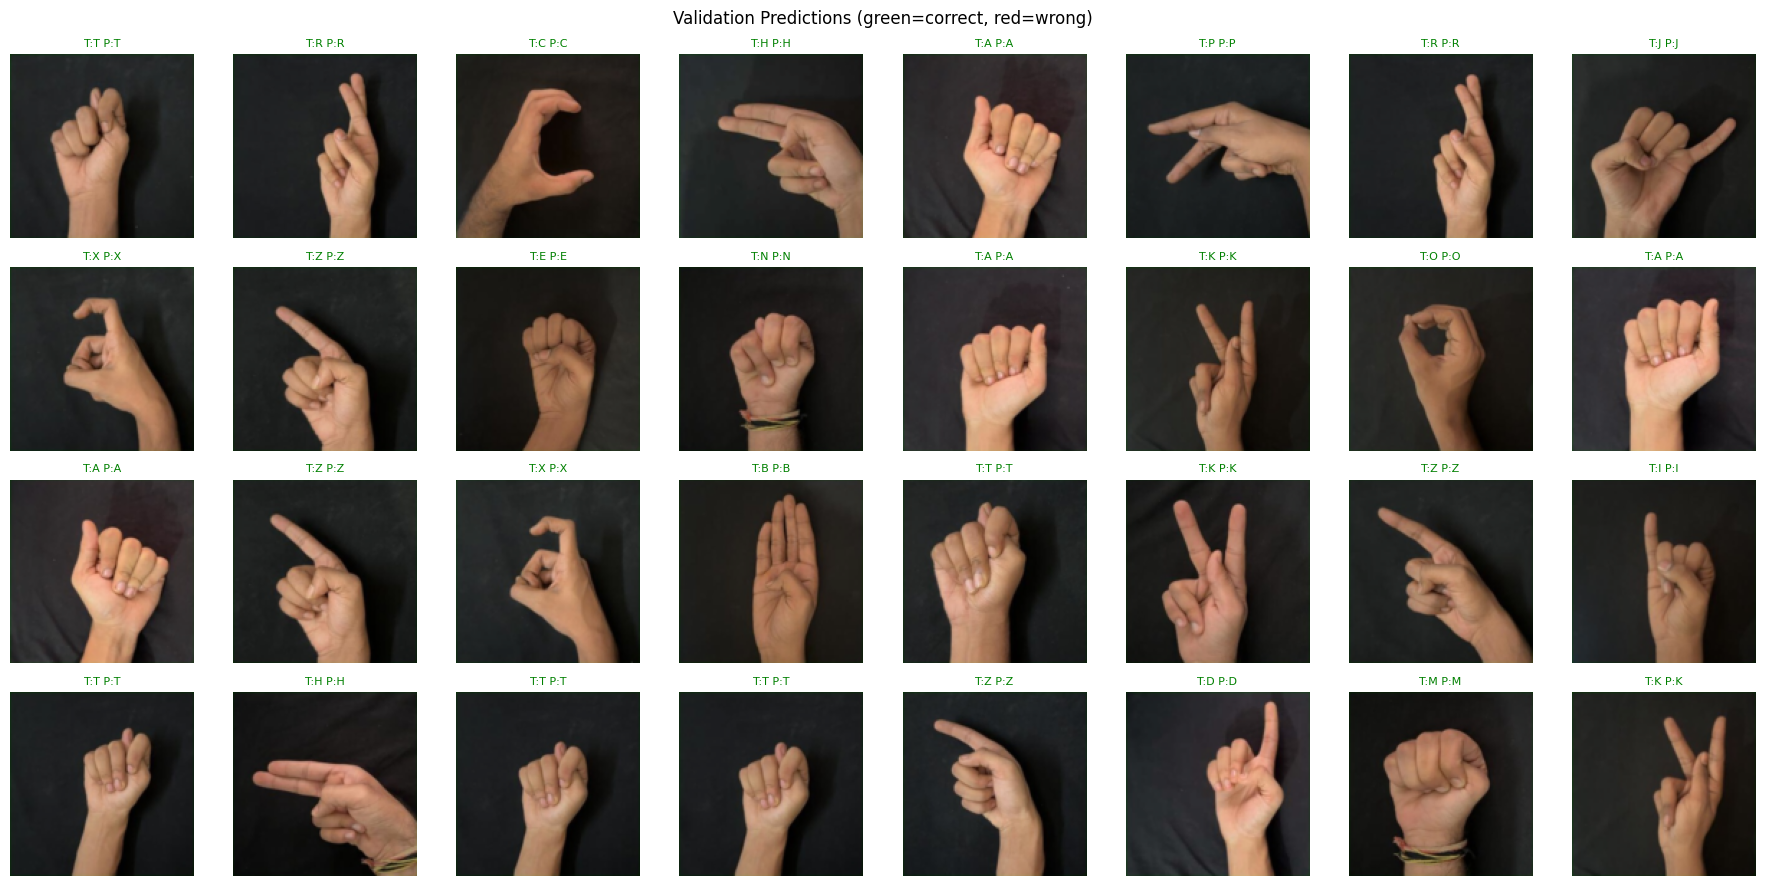

In [28]:
# ── Cell 10: Visualise Predictions ──────────────────────────────────────────

model.eval()
imgs, labels = next(iter(val_loader))
with torch.no_grad():
    preds = model(imgs.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
for ax, img, true, pred in zip(axes.flatten(), imgs[:32], labels[:32], preds[:32]):
    ax.imshow(denorm(img).permute(1,2,0).numpy())
    colour = "green" if true.item() == pred.item() else "red"
    ax.set_title(f"T:{classes[true]} P:{classes[pred]}", color=colour, fontsize=8)
    ax.axis("off")

plt.suptitle("Validation Predictions (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("val_predictions.png", dpi=120)
plt.show()

In [29]:
# ── Cell 11: Summary ─────────────────────────────────────────────────────────

print("=" * 50)
print("Saved artefacts:")
print(f"  Weights        → {CFG['save_path']}")
print(f"  Training curve → training_curves.png")
print(f"  Confusion mat  → confusion_matrix.png")
print(f"  Val preds      → val_predictions.png")
print("=" * 50)
print(f"\nBest Val Accuracy : {best_val_acc*100:.2f}%")
print(f"Checkpoint epoch  : {ckpt['epoch']}")
print(f"Checkpoint keys   : {list(ckpt.keys())}")
print("\nDone. Push asl_cnn_weights.pth to your branch for Task 2.")

Saved artefacts:
  Weights        → asl_cnn_weights.pth
  Training curve → training_curves.png
  Confusion mat  → confusion_matrix.png
  Val preds      → val_predictions.png

Best Val Accuracy : 100.00%
Checkpoint epoch  : 4
Checkpoint keys   : ['epoch', 'model_state', 'optimizer', 'val_acc', 'cfg', 'classes']

Done. Push asl_cnn_weights.pth to your branch for Task 2.


/kaggle/working/output_files_bundle